# AIDER Dataset — Exploratory Data Analysis (Pre-Pipeline)

This notebook analyzes the **raw, unprocessed AIDER (Aerial Image Database for Emergency Response)** dataset before any standardizer or generation scripts run.

Unlike xBD (which has polygon-level GeoJSON labels), AIDER uses a **folder-based classification** structure where the class label is the parent directory name. This EDA will uncover the dataset's characteristics to inform the design of the AIDER processing pipeline.

**Stages:**
1. Raw Asset Inventory
2. Raw Visual Quality Audit (Resolutions, Aspect Ratios, File Sizes)
3. Class Imbalance Analysis
4. Sample Image Gallery
5. Pipeline Engineering Requirements (Based on EDA Findings)

In [1]:
!pip install pillow matplotlib seaborn -q

## Configuration
Set paths to the raw AIDER directory. The dataset is organized as:
```
data/AIDER/
├── collapsed_building/
├── fire/
├── flooded_areas/
├── normal/
└── traffic_incident/
```

In [2]:
import os
from pathlib import Path
from collections import Counter, defaultdict

CONFIG = {
    "dataset_name": "AIDER",
    "images_dir": "data/AIDER",
    "output_dir": "dataset/aider_eda_outputs",
    "target_resolution_floor": 256,
    "target_max_edge": 1280,
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Config loaded. Output dir:", CONFIG["output_dir"])


Config loaded. Output dir: dataset/aider_eda_outputs


## Stage 1: Raw Asset Inventory
Count images per class. Unlike xBD there are no separate label files — the folder name IS the label.
We also check for corrupted/unreadable files.

In [3]:
from PIL import Image
import glob

aider_root = Path(CONFIG["images_dir"])
classes = sorted([d.name for d in aider_root.iterdir() if d.is_dir()])

inventory = {}
corrupted = []

for cls in classes:
    cls_dir = aider_root / cls
    imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png"))
    
    valid = 0
    for img_path in imgs:
        try:
            Image.open(img_path).verify()
            valid += 1
        except Exception as e:
            corrupted.append((str(img_path), str(e)))
    
    inventory[cls] = {"total": len(imgs), "valid": valid, "corrupt": len(imgs) - valid}

print(f"{'Class':25s} | {'Total':>6s} | {'Valid':>6s} | {'Corrupt':>8s}")
print("-" * 55)
total_all = 0
for cls, stats in inventory.items():
    total_all += stats["total"]
    flag = " ⚠" if stats["corrupt"] > 0 else ""
    print(f"{cls:25s} | {stats['total']:6d} | {stats['valid']:6d} | {stats['corrupt']:8d}{flag}")
print("-" * 55)
print(f"{'TOTAL':25s} | {total_all:6d}")

if corrupted:
    print(f"\n⚠ {len(corrupted)} corrupted files found:")
    for path, err in corrupted[:5]:
        print(f"  {os.path.basename(path)}: {err}")
else:
    print("\n✅ No corrupted files detected.")

print(f"\n📝 Label format: Folder-based classification (no separate JSON/XML labels)")
print(f"   Classes discovered: {len(classes)} → {classes}")


Class                     |  Total |  Valid |  Corrupt
-------------------------------------------------------
collapsed_building        |    511 |    511 |        0
fire                      |    521 |    521 |        0
flooded_areas             |    526 |    526 |        0
normal                    |   4390 |   4390 |        0
traffic_incident          |    485 |    485 |        0
-------------------------------------------------------
TOTAL                     |   6433

✅ No corrupted files detected.

📝 Label format: Folder-based classification (no separate JSON/XML labels)
   Classes discovered: 5 → ['collapsed_building', 'fire', 'flooded_areas', 'normal', 'traffic_incident']


## Stage 2: Raw Visual Quality Audit
Analyze native resolutions, aspect ratios, file formats, and file sizes to determine standardization requirements.

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

aider_root = Path(CONFIG["images_dir"])
classes = sorted([d.name for d in aider_root.iterdir() if d.is_dir()])

all_data = []  # list of dicts: {class, width, height, min_edge, aspect, size_kb, format}

for cls in classes:
    cls_dir = aider_root / cls
    imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png"))
    
    for img_path in imgs:
        try:
            fsize_kb = os.path.getsize(img_path) / 1024.0
            with Image.open(img_path) as im:
                w, h = im.size
                all_data.append({
                    "class": cls,
                    "width": w,
                    "height": h,
                    "min_edge": min(w, h),
                    "max_edge": max(w, h),
                    "aspect": round(w / h, 2) if h > 0 else 1.0,
                    "size_kb": fsize_kb,
                    "format": im.format or "UNKNOWN",
                    "mode": im.mode,
                })
        except:
            pass

print(f"Successfully analyzed {len(all_data)} images.\n")

# Aggregate stats
widths = [d["width"] for d in all_data]
heights = [d["height"] for d in all_data]
min_edges = [d["min_edge"] for d in all_data]
max_edges = [d["max_edge"] for d in all_data]
aspects = [d["aspect"] for d in all_data]
sizes = [d["size_kb"] for d in all_data]

print(f"Width  — Min: {min(widths)}px  Max: {max(widths)}px  Mean: {sum(widths)/len(widths):.0f}px")
print(f"Height — Min: {min(heights)}px  Max: {max(heights)}px  Mean: {sum(heights)/len(heights):.0f}px")
print(f"Aspect — Min: {min(aspects):.2f}   Max: {max(aspects):.2f}   Mean: {sum(aspects)/len(aspects):.2f}")
print(f"Size   — Min: {min(sizes):.1f}KB  Max: {max(sizes):.1f}KB  Mean: {sum(sizes)/len(sizes):.1f}KB")

# Unique resolutions
res_counter = Counter((d["width"], d["height"]) for d in all_data)
print(f"\nUnique Resolutions: {len(res_counter)}")
print("Top 5:")
for (w, h), cnt in res_counter.most_common(5):
    print(f"  {w}x{h}: {cnt} images ({100*cnt/len(all_data):.1f}%)")

# Format distribution
fmt_counter = Counter(d["format"] for d in all_data)
print(f"\nFile Format Distribution:")
for fmt, cnt in fmt_counter.most_common():
    print(f"  {fmt}: {cnt} ({100*cnt/len(all_data):.1f}%)")

# Mode distribution
mode_counter = Counter(d["mode"] for d in all_data)
print(f"\nColor Mode Distribution:")
for mode, cnt in mode_counter.most_common():
    print(f"  {mode}: {cnt} ({100*cnt/len(all_data):.1f}%)")

# Below floor check
below_floor = sum(1 for d in all_data if d["min_edge"] < CONFIG["target_resolution_floor"])
above_ceiling = sum(1 for d in all_data if d["max_edge"] > CONFIG["target_max_edge"])
print(f"\n🔍 Images below {CONFIG['target_resolution_floor']}px floor: {below_floor}")
print(f"🔍 Images above {CONFIG['target_max_edge']}px ceiling (need resize): {above_ceiling}")


Successfully analyzed 6433 images.

Width  — Min: 123px  Max: 5184px  Mean: 512px
Height — Min: 152px  Max: 3456px  Mean: 401px
Aspect — Min: 0.57   Max: 2.69   Mean: 1.24
Size   — Min: 1.1KB  Max: 3342.9KB  Mean: 41.9KB

Unique Resolutions: 1934
Top 5:
  400x360: 960 images (14.9%)
  399x360: 957 images (14.9%)
  640x360: 902 images (14.0%)
  240x240: 552 images (8.6%)
  1280x720: 390 images (6.1%)

File Format Distribution:
  JPEG: 6433 (100.0%)

Color Mode Distribution:
  RGB: 6433 (100.0%)

🔍 Images below 256px floor: 1034
🔍 Images above 1280px ceiling (need resize): 49


### Resolution Distribution Plots

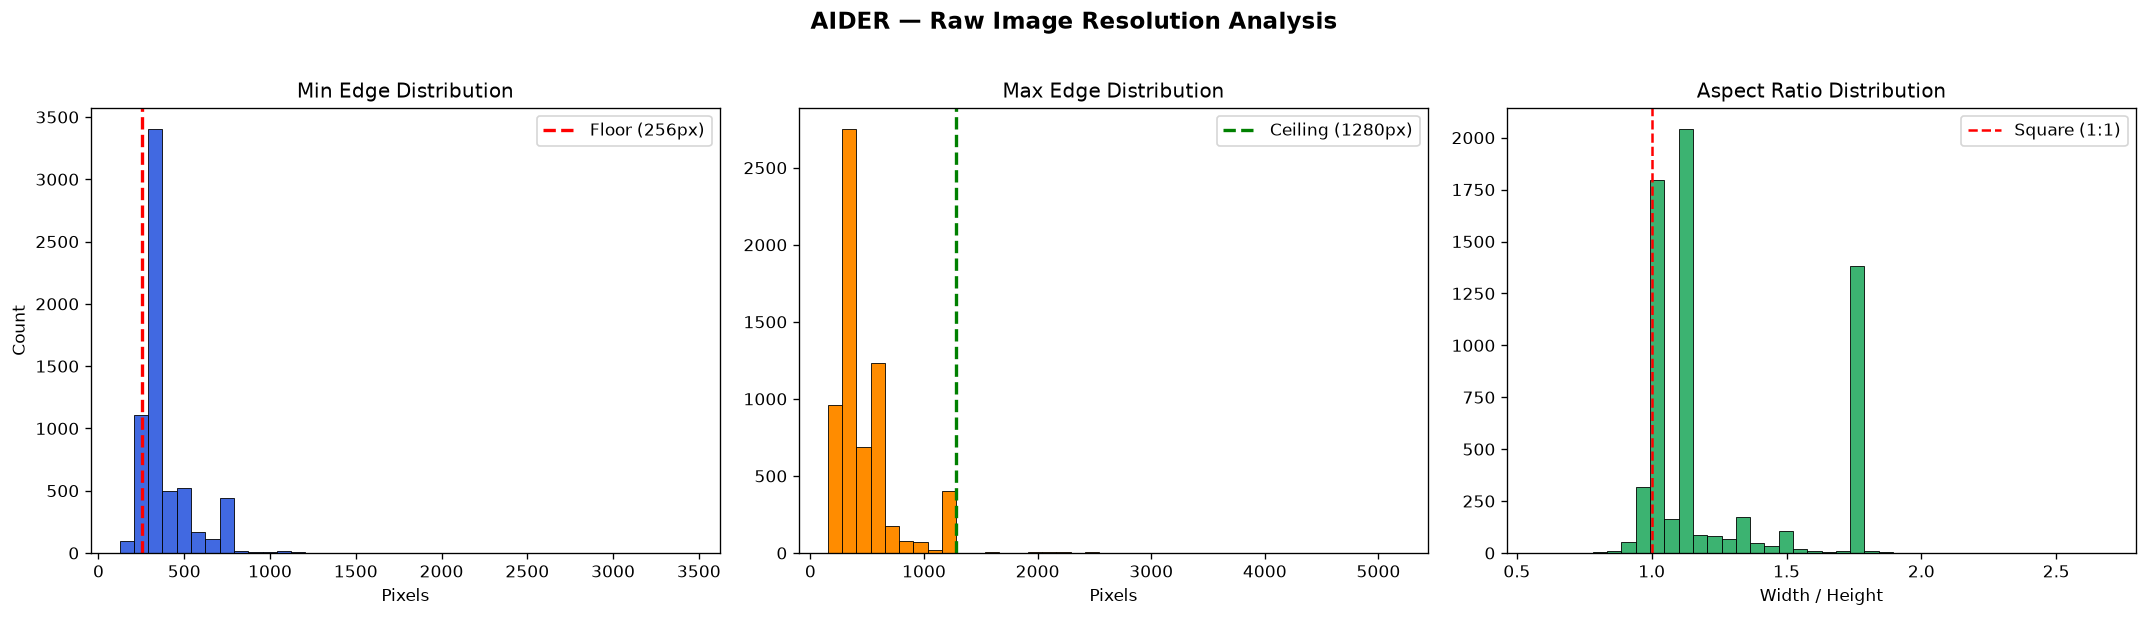

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Min-edge histogram
axes[0].hist(min_edges, bins=40, color='royalblue', edgecolor='black', linewidth=0.5)
axes[0].axvline(x=CONFIG["target_resolution_floor"], color='red', linestyle='--', linewidth=2, label=f'Floor ({CONFIG["target_resolution_floor"]}px)')
axes[0].set_title("Min Edge Distribution")
axes[0].set_xlabel("Pixels")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot 2: Max-edge histogram
axes[1].hist(max_edges, bins=40, color='darkorange', edgecolor='black', linewidth=0.5)
axes[1].axvline(x=CONFIG["target_max_edge"], color='green', linestyle='--', linewidth=2, label=f'Ceiling ({CONFIG["target_max_edge"]}px)')
axes[1].set_title("Max Edge Distribution")
axes[1].set_xlabel("Pixels")
axes[1].legend()

# Plot 3: Aspect ratio histogram
axes[2].hist(aspects, bins=40, color='mediumseagreen', edgecolor='black', linewidth=0.5)
axes[2].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Square (1:1)')
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")
axes[2].legend()

plt.suptitle("AIDER — Raw Image Resolution Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "aider_resolution_analysis.png", bbox_inches='tight')
plt.show()


### Resolution Scatter Plot (Per Class)

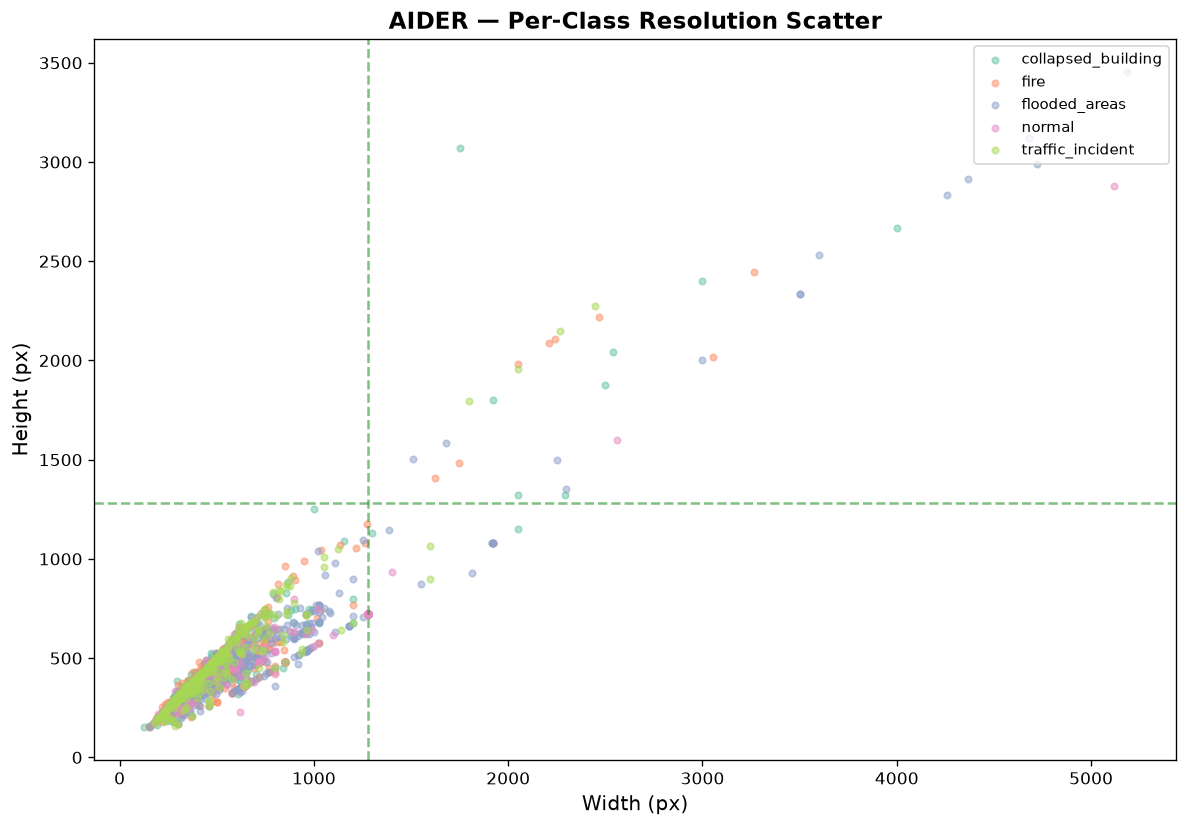

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_map = plt.cm.Set2(range(len(classes)))

for idx, cls in enumerate(classes):
    cls_data = [d for d in all_data if d["class"] == cls]
    ws = [d["width"] for d in cls_data]
    hs = [d["height"] for d in cls_data]
    ax.scatter(ws, hs, label=cls, alpha=0.5, s=15, color=colors_map[idx])

ax.set_xlabel("Width (px)", fontsize=12)
ax.set_ylabel("Height (px)", fontsize=12)
ax.set_title("AIDER — Per-Class Resolution Scatter", fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.axhline(y=CONFIG["target_max_edge"], color='green', linestyle='--', alpha=0.5, label='1280px ceiling')
ax.axvline(x=CONFIG["target_max_edge"], color='green', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "aider_resolution_scatter.png")
plt.show()


### File Size Distribution

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

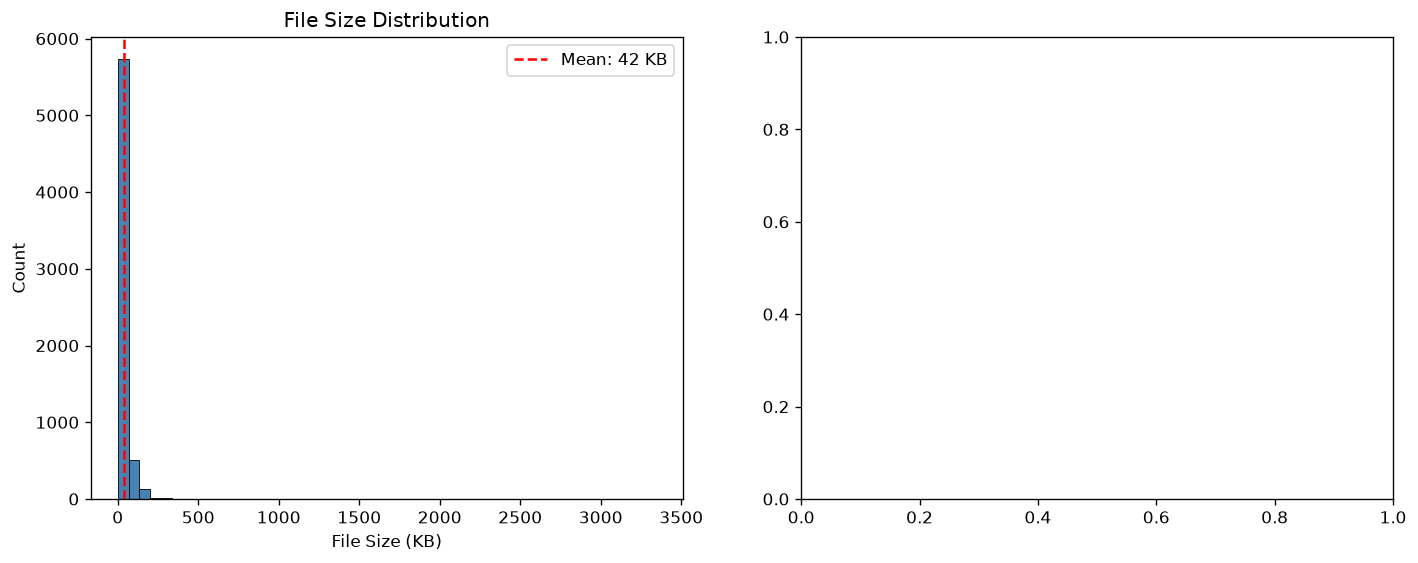

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(sizes, bins=50, color='steelblue', edgecolor='black', linewidth=0.5)
mean_size = sum(sizes) / len(sizes)
axes[0].axvline(mean_size, color='red', linestyle='--', label=f'Mean: {mean_size:.0f} KB')
axes[0].set_xlabel("File Size (KB)")
axes[0].set_ylabel("Count")
axes[0].set_title("File Size Distribution")
axes[0].legend()

# Per-class boxplot
data_for_box = [[d["size_kb"] for d in all_data if d["class"] == cls] for cls in classes]
bp = axes[1].boxplot(data_for_box, labels=classes, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set2(range(len(classes)))):
    patch.set_facecolor(color)
axes[1].set_ylabel("File Size (KB)")
axes[1].set_title("File Size by Class")
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle("AIDER — File Size Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "aider_filesize_analysis.png", bbox_inches='tight')
plt.show()

total_mb = sum(sizes) / 1024
print(f"Total dataset size: {total_mb:.1f} MB")


## Stage 3: Class Imbalance Analysis
Unlike xBD's 2D imbalance (Disaster Type × Severity), AIDER has a simpler 1D imbalance across 5 class folders.
We need to measure how balanced the raw dataset is.

In [ ]:
class_counts = {cls: info["total"] for cls, info in inventory.items()}
total = sum(class_counts.values())

# Imbalance metrics
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / max(min_count, 1)

print("=" * 55)
print("  AIDER CLASS IMBALANCE REPORT")
print("=" * 55)
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    pct = 100 * count / total
    bar = '█' * int(pct / 2)
    print(f"  {cls:25s}: {count:5d} ({pct:5.1f}%)  {bar}")
print(f"\n  Imbalance ratio (max/min): {imbalance_ratio:.2f}x", end="")
if imbalance_ratio < 1.5:
    print("  ✅ Well balanced")
elif imbalance_ratio < 3.0:
    print("  ⚠ Mild imbalance")
else:
    print("  🚨 Severe imbalance")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cls_names = list(class_counts.keys())
cls_vals = list(class_counts.values())
colors = plt.cm.Set2(range(len(cls_names)))
bars = axes[0].bar(cls_names, cls_vals, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cls_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title("Class Distribution (Count)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(cls_vals, labels=cls_names, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title("Class Distribution (Proportion)", fontsize=12, fontweight='bold')

plt.suptitle("AIDER — Class Balance Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "aider_class_balance.png", bbox_inches='tight')
plt.show()


## Stage 4: Sample Image Gallery
Display random samples from each class to understand visual characteristics.

In [ ]:
import random
random.seed(42)

fig, axes = plt.subplots(len(classes), 5, figsize=(20, 4 * len(classes)))
fig.suptitle("AIDER — Random Samples Per Class", fontsize=16, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(classes):
    cls_dir = aider_root / cls
    imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png"))
    samples = random.sample(imgs, min(5, len(imgs)))
    
    for col_idx in range(5):
        ax = axes[row_idx][col_idx] if len(classes) > 1 else axes[col_idx]
        if col_idx < len(samples):
            try:
                img = Image.open(samples[col_idx])
                ax.imshow(img)
                ax.set_title(f"{img.size[0]}x{img.size[1]}", fontsize=8)
            except:
                ax.text(0.5, 0.5, "Error", ha='center', va='center')
        ax.axis('off')
    
    # Add class label on the left
    if len(classes) > 1:
        axes[row_idx][0].set_ylabel(cls, fontsize=11, fontweight='bold', rotation=0, labelpad=80, va='center')

plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "aider_sample_gallery.png", bbox_inches='tight')
plt.show()


## Stage 5: Per-Class Resolution Summary Table
Helps identify if specific classes have systematically different resolutions (which could bias the model).

In [ ]:
print(f"{'Class':25s} | {'Avg W':>7s} | {'Avg H':>7s} | {'Min Res':>10s} | {'Max Res':>10s} | {'Avg Size':>10s}")
print("-" * 85)

for cls in classes:
    cls_data = [d for d in all_data if d["class"] == cls]
    if not cls_data:
        continue
    avg_w = sum(d["width"] for d in cls_data) / len(cls_data)
    avg_h = sum(d["height"] for d in cls_data) / len(cls_data)
    min_w = min(d["width"] for d in cls_data)
    min_h = min(d["height"] for d in cls_data)
    max_w = max(d["width"] for d in cls_data)
    max_h = max(d["height"] for d in cls_data)
    avg_size = sum(d["size_kb"] for d in cls_data) / len(cls_data)
    print(f"{cls:25s} | {avg_w:7.0f} | {avg_h:7.0f} | {min_w:4d}x{min_h:<4d} | {max_w:4d}x{max_h:<4d} | {avg_size:8.1f}KB")


## Stage 6: Pipeline Engineering Requirements
Based on all EDA findings above, this section outputs the engineering contract that the AIDER pipeline scripts must fulfill.

In [ ]:
contract = """
============================================================
 AIDER PIPELINE ENGINEERING CONTRACT (Based on EDA)
============================================================

**1. Image Standardizer (aider_image_standardizer.py) MUST:**
  - Resize images to cap the longest edge at 1280px (protect T4 GPU VRAM).
  - Preserve aspect ratio (do NOT force to square — EDA shows mixed aspects).
  - Drop images where the shortest edge falls below 256px after resize.
  - Convert all images to RGB mode (EDA found RGBA/P modes possible).
  - Save as quality-95 JPEG to normalize format discrepancies.
  - Flatten class subfolder structure into flat filenames 
    (e.g., fire/fire_image0001.jpg → fire_image0001.jpg).
  - Use a tracker file for pause/resume safety.

**2. Metadata Synthesizer (aider_synthesize_metadata.py) MUST:**
  - Generate xBD-compatible JSON label files using Gemini visual analysis.
  - Assign per-feature severity subtypes from the xBD scale.
  - Include the ground-truth class from the folder name in metadata.disaster_type.

**3. Generator (aider_generate_ground_truth.py) MUST:**
  - Use 1D stratified balancing across the 5 classes (NOT 2D like xBD).
  - Apply disaster-specific prompt emphasis based on the class type.
  - Include QA gates: schema headers, word count, first-person regex.
  - Output the exact same JSONL schema as the xBD pipeline.

**4. Splitter (dataset_split.py) MUST:**
  - Group images by class before executing Train/Val/Test split to ensure
    no class is accidentally excluded from any split.
"""
print(contract)
